In [ ]:
# pip install --upgrade numpy
!pip install "numpy>=2.0.0,<2.5.0"

In [ ]:
# # run in unavailable
# !pip install --upgrade pip
# !pip install jax jaxlib jaxopt tinygp numpyro scikit-learn pandas matplotlib scipy

In [ ]:
from dataclasses import dataclass
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import scipy.ndimage as ndimage

import jax
import jax.numpy as jnp
import jaxopt

import tinygp
from tinygp import kernels, transforms
# =====================================================
@dataclass
class GPParams:

    train_fraction: float
    random_seed: int
    normalise: bool
    optimiser_restarts: int
    
class GPModel:

    def __init__(self, train_fraction=0.9, random_seed=7, normalise=True, optimiser_restarts=10):
    
        self.p = GPParams(train_fraction, random_seed, normalise, optimiser_restarts)
        
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None

        # Objects created for standardisation workflow
        self.X_scaler = StandardScaler()
        self.y_scaler = StandardScaler()

        # Hyperparameters (will be initialized in the fitting step)
        self.params = None
        
    # --------------------------------------------------------------------------
    # randomise parameters:
    def randomise_params(self, seed):

        key = jax.random.PRNGKey(seed)
        k1, k2, k3 = jax.random.split(key, 3)
        
        initial_params = {
            "lengthscales": 0.5 + 0.3 * jax.random.normal(k1, (8,)),
            "log_sigma_f": 0.2 * jax.random.normal(k2),
            "log_noise": jnp.log(1e-2) + 0.3 * jax.random.normal(k3) ,
        }
        
        return initial_params
    
    # --------------------------------------------------------------------------
    # Data loader; pre-processing
    def load_data(self, X, y, train_idx=None, test_idx=None):
        # Train/Test Split
        # Note: Tests data are not scaled
        if train_idx is None or test_idx is None:
            X_train, X_test, y_train, y_test = train_test_split(X, y, 
                train_size=self.p.train_fraction, random_state=self.p.random_seed)

        else:         
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
        #-----------------------------------
        # split contnuous and periodic inputs
        X_tr_cont = X_train[:, :7]
        
        # Scale( Fit & transform) continuous features: (X-X_hat)/var(X):
        X_tr_scaled_cont = self.X_scaler.fit_transform(X_tr_cont)

        # Scale output: (y-y_hat)/var(y), scaling test data from training pars
        y_train_scaled = self.y_scaler.fit_transform(y_train.reshape(-1,1))
        
        # Recombine features 
        X_train_scaled = np.hstack((X_tr_scaled_cont, X_train[:, 7:8]))
        # X_test_scaled = np.hstack((X_te_scaled_cont, X_test[:, 7:8]))

        # Convert to JAX arrays
        self.X_train = jnp.array(X_train_scaled)
        self.y_train = jnp.array(y_train_scaled).flatten()
        
        self.X_test = jnp.array(X_test)
        self.y_test = jnp.array(y_test).flatten()

    # --------------------------------------------------------------------------
    # Build hetro Kernel
    def hetro_Kernel(self, params):
        # params['lengthscales']; shape (8,)
        ell = jnp.exp(params["lengthscales"])
        sigma_f = jnp.exp(params["log_sigma_f"])
        # period = jnp.exp(params["period"])
        
        def make_kernel(kernel_cls, dim_idx):
            transform_matrix = jnp.zeros((1, 8)).at[0, dim_idx].set(1.0 / ell[dim_idx])
            return tinygp.transforms.Linear(transform_matrix, kernel_cls())


        k_rbf = (make_kernel(kernels.ExpSquared, 0) *
                 make_kernel(kernels.ExpSquared, 1) *
                 make_kernel(kernels.ExpSquared, 4))
    
        k_matern32 = (make_kernel(kernels.Matern32, 2) *
                      make_kernel(kernels.Matern32, 5))
    
        k_matern52 = (make_kernel(kernels.Matern52, 3) *
                      make_kernel(kernels.Matern52, 6))
        
        # Periodic kernel: (final index 7); ExpSineSquared
        p_matrix = jnp.zeros((1, 8)).at[0, 7].set(1.0 / np.pi)
        k_periodic = tinygp.transforms.Linear(p_matrix, 
                kernels.ExpSineSquared(scale=ell[7], gamma=2.0))
            
        # Complete Tensor Product Kernel
        composite_kernel = (sigma_f**2) * (k_rbf * k_matern32 * k_matern52 * k_periodic)        
        
        return composite_kernel
    
    # --------------------------------------------------------------------------
    # Build the prior function
    def build_gpr(self, params, X):
        # custom hetro kernel
        kernel = self.hetro_Kernel(params)
        # obs noise
        noise = jnp.exp(params["log_noise"])
         # build the GP with noise: cov = K+var(noise) 
        # Construct the Gaussian process prior:
        gp = tinygp.GaussianProcess(kernel, X, diag=noise)

        return gp
        
    # --------------------------------------------------------------------------
    #Training phase: Optimise hyperparameters; train gp
    # --------------------------------------------------------------------------
    def loss(self, params):
        gp = self.build_gpr(params, self.X_train)
        # - log {p(y)}
        return -gp.log_probability(self.y_train)
        
    # --------------------------------------------------------------------------
    def opt_hyper(self):
        
        best_loss = np.inf
        
        # JAX-compatible minimizer ----> loop ---> convergence
        solver = jaxopt.ScipyMinimize(method="L-BFGS-B", fun=self.loss)

        # keep the params set with minimal loss
        for i in range(self.p.optimiser_restarts):
            init = self.randomise_params(seed=self.p.random_seed + i)
            res = solver.run(init)
            
            if res.state.fun_val < best_loss:
                best_loss = res.state.fun_val
                self.params = res.params
        
    # --------------------------------------------------------------------------
    def GP_train(self, file_name):
        df = pd.read_csv(file_name)
        # 8D input features ref
        feature_cols = ["fiber_vf", "f_r", "mu", "sigma", "db_t", 
                        "crc_no", "debond_fraction", "base_angle"]
        
        # (N, 8) input space
        X_data = df[feature_cols].to_numpy()
        # (N, 1) target output
        y_data = df["P_eff"].to_numpy()
        
        self.load_data(X_data, y_data)
        
        # Run the optimisation loop; model fit pars
        self.opt_hyper()

    # --------------------------------------------------------------------------
    def predict(self, X_in):
        # Vectorise input array [:, d]
        X_in = jnp.atleast_2d(X_in)
        # inout rescling info
        x_mean = jnp.array(self.X_scaler.mean_)
        x_scale = jnp.array(self.X_scaler.scale_)
        
        X_scaled = (X_in[:, :7] - x_mean) / x_scale
        x_scaled = jnp.hstack((X_scaled, X_in[:, 7:8]))
        
        prior_gp = self.build_gpr(self.params, self.X_train)
        log_evd, posterior_gp = prior_gp.condition(self.y_train, x_scaled)
        # output rescling info
        y_mean = float(self.y_scaler.mean_[0])
        y_scale = float(self.y_scaler.scale_[0])
        # .inverse_transform
        mu = (posterior_gp.mean * y_scale) + y_mean
        std = jnp.sqrt(posterior_gp.variance) * y_scale
        
        return mu, std, log_evd
    

In [5]:
# Run first test
if __name__ == "__main__":
    # Load High Fidelity Data:
    df = pd.read_csv("simulation_200.csv")
    # 8D input features ref
    feature_cols = ["fiber_vf", "f_r", "mu", "sigma", "db_t", 
                    "crc_no", "debond_fraction", "base_angle"]
    
    # (N, 8) input space
    X_data = df[feature_cols].to_numpy()
    # (N, 1) target output
    y_data = df["P_eff"].to_numpy()
    
    GPR = GPModel()
    GPR.load_data(X_data, y_data)
    
    # Run the optimisation loop; model fit pars
    GPR.opt_hyper()
    
    # Make predicttion on the (scaled) test features + measure execution time per sample
    t0 = time.perf_counter()
    mu, std, log_evd = GPR.predict(GPR.X_test)
    per_sample_ms = ((time.perf_counter() - t0) / len(GPR.X_test)) * 1000.0
    
    # y_true = GPR.y_scaler.inverse_transform(np.array(GPR.y_test).reshape(-1, 1)).flatten()
    y_true = GPR.y_test
    
    rmse = np.sqrt(mean_squared_error(y_true, mu))
    mae = mean_absolute_error(y_true, mu)
    r2 = r2_score(y_true, mu)
    
    print("\n" + "="*40)
    print("     NUMERICAL PERFORMANCE REPORT")
    print("="*40)
    print(f"Log Marginal Evidence: {float(log_evd):.4f}")
    print(f"Test RMSE:             {rmse:.4f}")
    print(f"Test MAE:              {mae:.4f}")
    print(f"Test R² Predictive Score: {r2:.4f}")
    print(f"GP Eval Time (per sample): {per_sample_ms:.4f} ms")
    print("="*40)
    print("done!")


     NUMERICAL PERFORMANCE REPORT
Log Marginal Evidence: -29.6131
Test RMSE:             0.0042
Test MAE:              0.0034
Test R² Predictive Score: 0.9851
GP Eval Time (per sample): 309.5310 ms
done!


In [10]:
# Run 10-fold test
if __name__ == "__main__":
    
    # Load High Fidelity Data:
    df = pd.read_csv("simulation_200.csv")
    # 8D input features ref
    feature_cols = ["fiber_vf", "f_r", "mu", "sigma", "db_t", 
                    "crc_no", "debond_fraction", "base_angle"]
    
    # (N, 8) input space
    X_data = df[feature_cols].to_numpy()
    # (N, 1) target output
    y_data = df["P_eff"].to_numpy()
    
    # Initialise 10-Fold Splitter
    kf = KFold(n_splits=10, shuffle=True, random_state=7)

    all_splits = []
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    
    print("="*50)
    print("     LAUNCHING 10-FOLD CROSS-VALIDATION LOOPS")
    print("="*50)
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(X_data, y_data)):

        all_splits.append((train_idx, test_idx))
    
        # Instantiate custom model call
        GPR = GPModel(random_seed=7 + fold, optimiser_restarts=40)
        
        GPR.load_data(X_data, y_data, train_idx, test_idx) 
        
        # Run the optimisation loop; model fit pars
        GPR.opt_hyper()
        
        # Make predicttion on the (scaled) test features
        mu_pred, std_pred, lme = GPR.predict(GPR.X_test)
        y_true = GPR.y_test
        
        # Evaluate metrics
        fold_r2 = r2_score(y_true, mu_pred)
        fold_rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        fold_mae = mean_absolute_error(y_true, mu_pred)
        
        r2_scores.append(fold_r2)
        rmse_scores.append(fold_rmse)
        mae_scores.append(fold_mae)
        
        print(f"Fold {fold+1:02d} | R²: {fold_r2:.4f} | RMSE: {fold_rmse:.4e} | MAE: {fold_mae:.4e}")
        print(f"Log Marginal Evidence    : {float(lme):.4f}")
        
    print("="*50)
    print("    FINAL 10-FOLD AGGREGATED STATISTICS")
    print("="*50)
    print(f"Mean Predictive R² Score : {np.mean(r2_scores):.4f} (± {np.std(r2_scores):.4f})")
    print(f"Mean Fold RMSE           : {np.mean(rmse_scores):.4e}")
    print(f"Mean Fold MAE            : {np.mean(mae_scores):.4e}")
    print("="*50)

     LAUNCHING 10-FOLD CROSS-VALIDATION LOOPS
Fold 01 | R²: 0.9851 | RMSE: 4.2406e-03 | MAE: 3.3838e-03
Log Marginal Evidence    : -29.6100
Fold 02 | R²: 0.8706 | RMSE: 1.5533e-02 | MAE: 7.6914e-03
Log Marginal Evidence    : -18.1573
Fold 03 | R²: 0.9784 | RMSE: 5.9133e-03 | MAE: 4.2203e-03
Log Marginal Evidence    : -29.7041
Fold 04 | R²: 0.9721 | RMSE: 5.8386e-03 | MAE: 4.3805e-03
Log Marginal Evidence    : -27.7144
Fold 05 | R²: 0.8228 | RMSE: 1.3092e-02 | MAE: 8.0383e-03
Log Marginal Evidence    : -3.2160
Fold 06 | R²: 0.9193 | RMSE: 1.0649e-02 | MAE: 6.2350e-03
Log Marginal Evidence    : -16.3965
Fold 07 | R²: 0.8858 | RMSE: 9.0294e-03 | MAE: 6.5863e-03
Log Marginal Evidence    : -18.2683
Fold 08 | R²: 0.9802 | RMSE: 4.4468e-03 | MAE: 3.7243e-03
Log Marginal Evidence    : -26.5913
Fold 09 | R²: 0.9474 | RMSE: 8.4862e-03 | MAE: 4.6779e-03
Log Marginal Evidence    : -22.9842
Fold 10 | R²: 0.8998 | RMSE: 1.0847e-02 | MAE: 6.1468e-03
Log Marginal Evidence    : -11.9685
    FINAL 10-FO

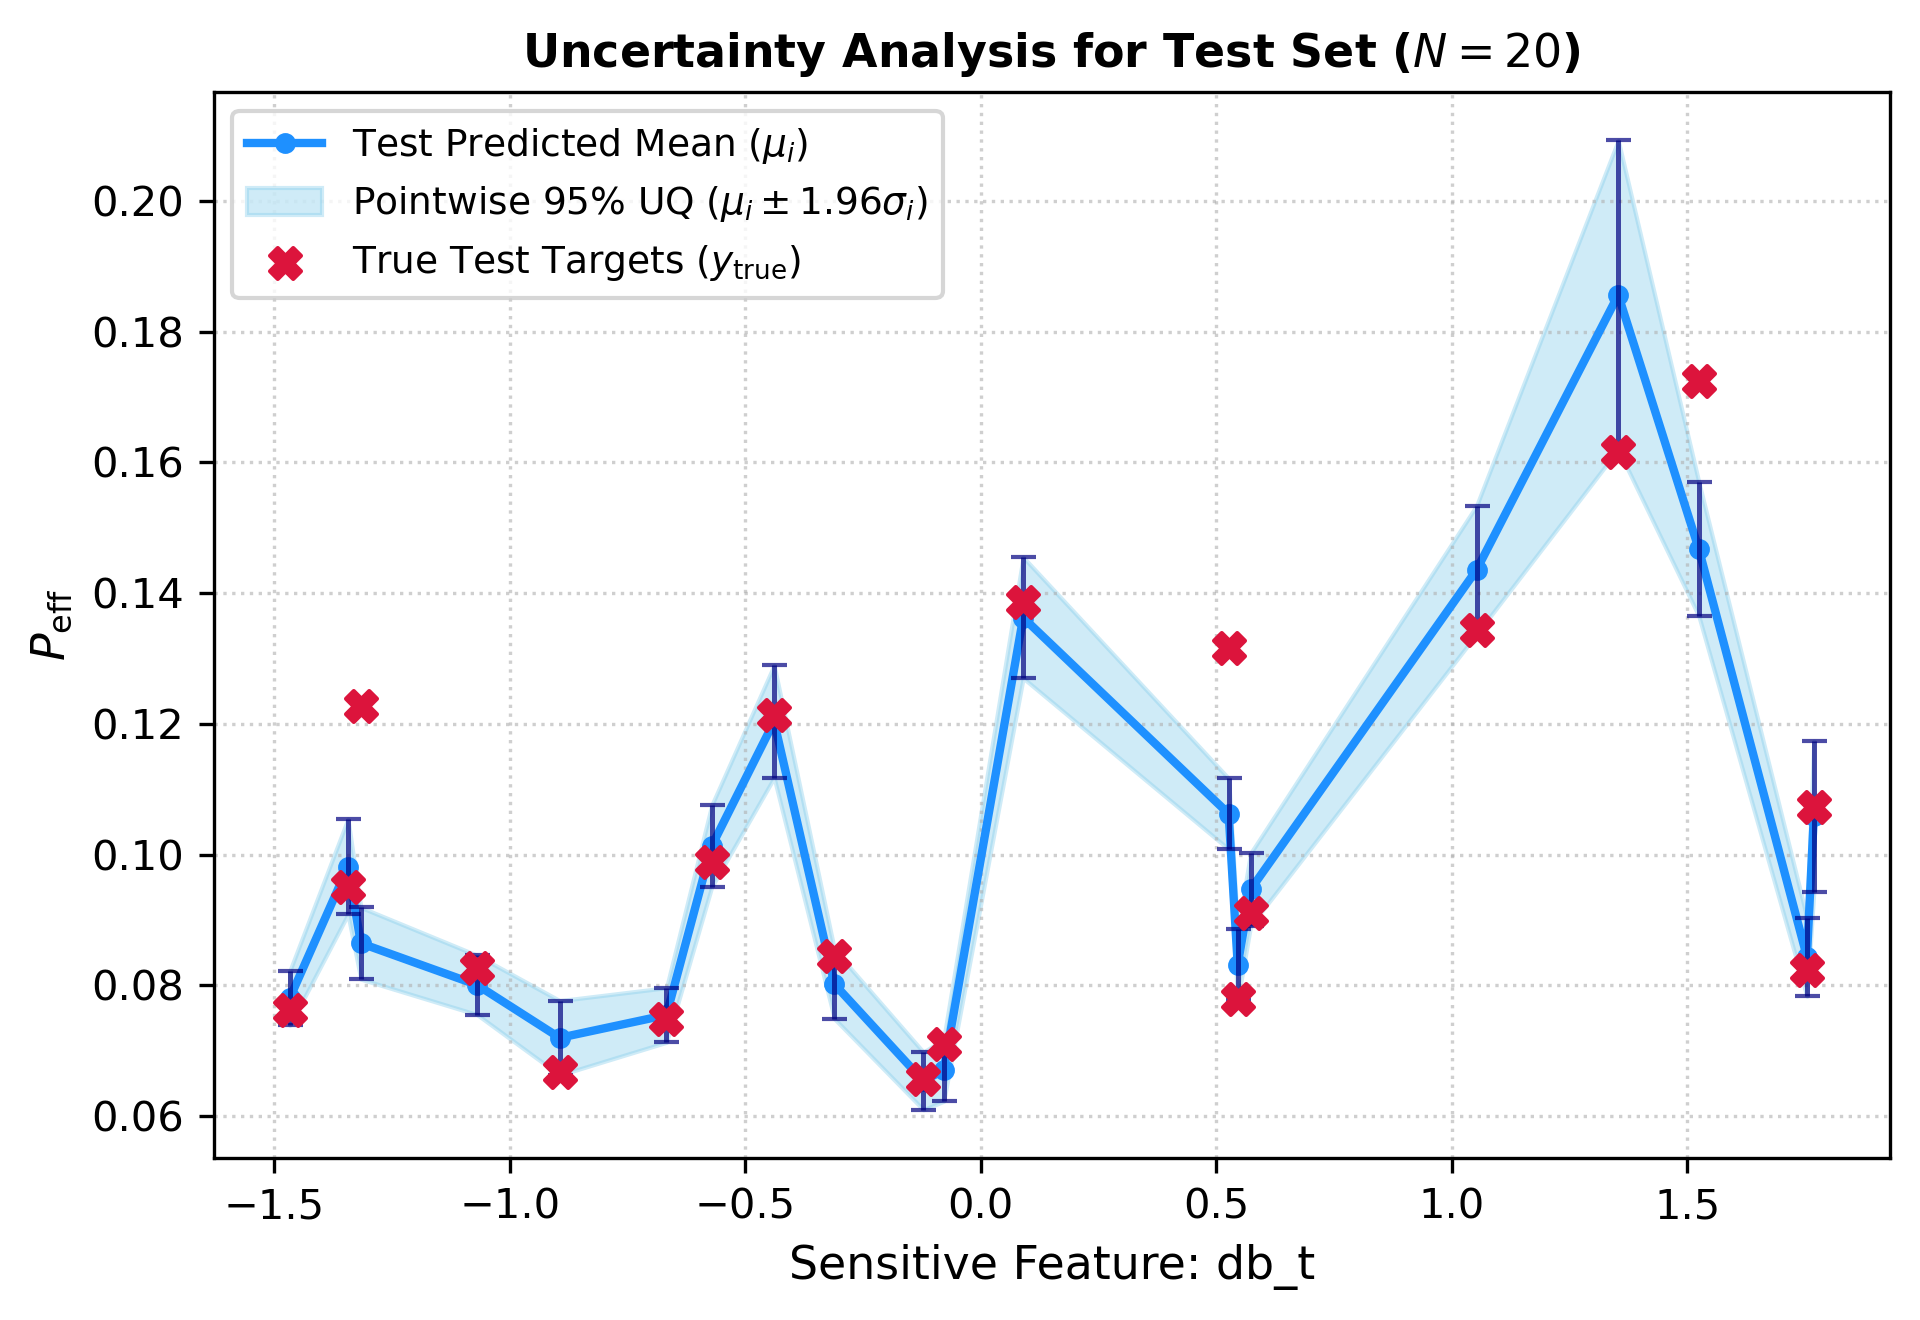

In [16]:
# TEST UQ PLOT ALONG SENSITIVE FEATURE
# ==============================================================================
if __name__ == "__main__":
    plt.figure(figsize=(6.5, 4.5), dpi=300)
    
    # Retrieve Target Fold indices
    target_fold = 5
    train_idx, test_idx = all_splits[target_fold-1]
    if len(all_splits)>=target_fold:
        # Re-instantiate & fit GPR for Target Fold
        GPR = GPModel(random_seed=7 + target_fold - 1, optimiser_restarts=40)
        GPR.load_data(X_data, y_data, train_idx, test_idx)
        params = GPR.opt_hyper()
    else:
        
        # O.W. Cluster & Train GP
        kmeans = KMeans(n_clusters=5, random_state=42).fit(X_data)
        labels = kmeans.labels_
        
        train_idx = np.where(labels != 4)[0]
        test_idx  = np.where(labels == 4)[0]
    
        GPR.load_data(X_data, y_data, train_idx, test_idx)
        GPR.opt_hyper()
    
    
    # Find the feature index with highest impact (shortest lengthscale)
    feat_idx = np.argmin(GPR.params["lengthscales"]) 
    feat_name = feature_cols[feat_idx]
    
    # Extract and sort test feature values (smooth plot)
    x_test_feat = GPR.X_test[:, feat_idx]
    sort_idx    = np.argsort(x_test_feat)
    x_feat_sort = x_test_feat[sort_idx]
    
    
    # Make prediction
    mu_test, std_test, _ = GPR.predict(GPR.X_test)
    # y_test_true = GPR.y_scaler.inverse_transform(np.array(GPR.y_test).reshape(-1, 1)).flatten()
    y_test_true = GPR.y_test
    
    
    # Sort predcited values - corres./ to x_idx
    mu_sort      = mu_test[sort_idx]
    std_sort     = std_test[sort_idx]
    y_true_sort  = y_test_true[sort_idx]
    
    # Plot: (Mu_i +/- 1.96 * Sigma_i)
    plt.plot(x_feat_sort, mu_sort, color='dodgerblue', lw=2, marker='o', ms=4, label=r'Test Predicted Mean ($\mu_i$)')
    
    plt.fill_between(
        x_feat_sort, 
        mu_sort - 1.96 * std_sort, 
        mu_sort + 1.96 * std_sort, 
        color='skyblue', alpha=0.4, 
        label=r'Pointwise 95% UQ ($\mu_i \pm 1.96\sigma_i$)'
    )
    
    # Overlay Ground Truth
    plt.scatter(
        x_feat_sort, y_true_sort, 
        color='crimson', marker='X', s=55, zorder=5, 
        label=r'True Test Targets ($y_{\mathrm{true}}$)'
    )
    
    # Error Bars for Non-Uniform Var:
    plt.errorbar(
        x_feat_sort, mu_sort, yerr=1.96 * std_sort,
        fmt='none', ecolor='navy', alpha=0.7, elinewidth=1.2, capsize=3, zorder=4
    )
    plt.xlabel(f'Sensitive Feature: {feat_name}', fontsize=11)
    plt.ylabel(r'$P_{\mathrm{eff}}$', fontsize=11)
    plt.title('Uncertainty Analysis for Test Set ($N=20$)', fontsize=11, fontweight='bold')
    plt.legend(loc='best', frameon=True, fontsize=9)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig("fig_test_UQ.png")
    plt.show()

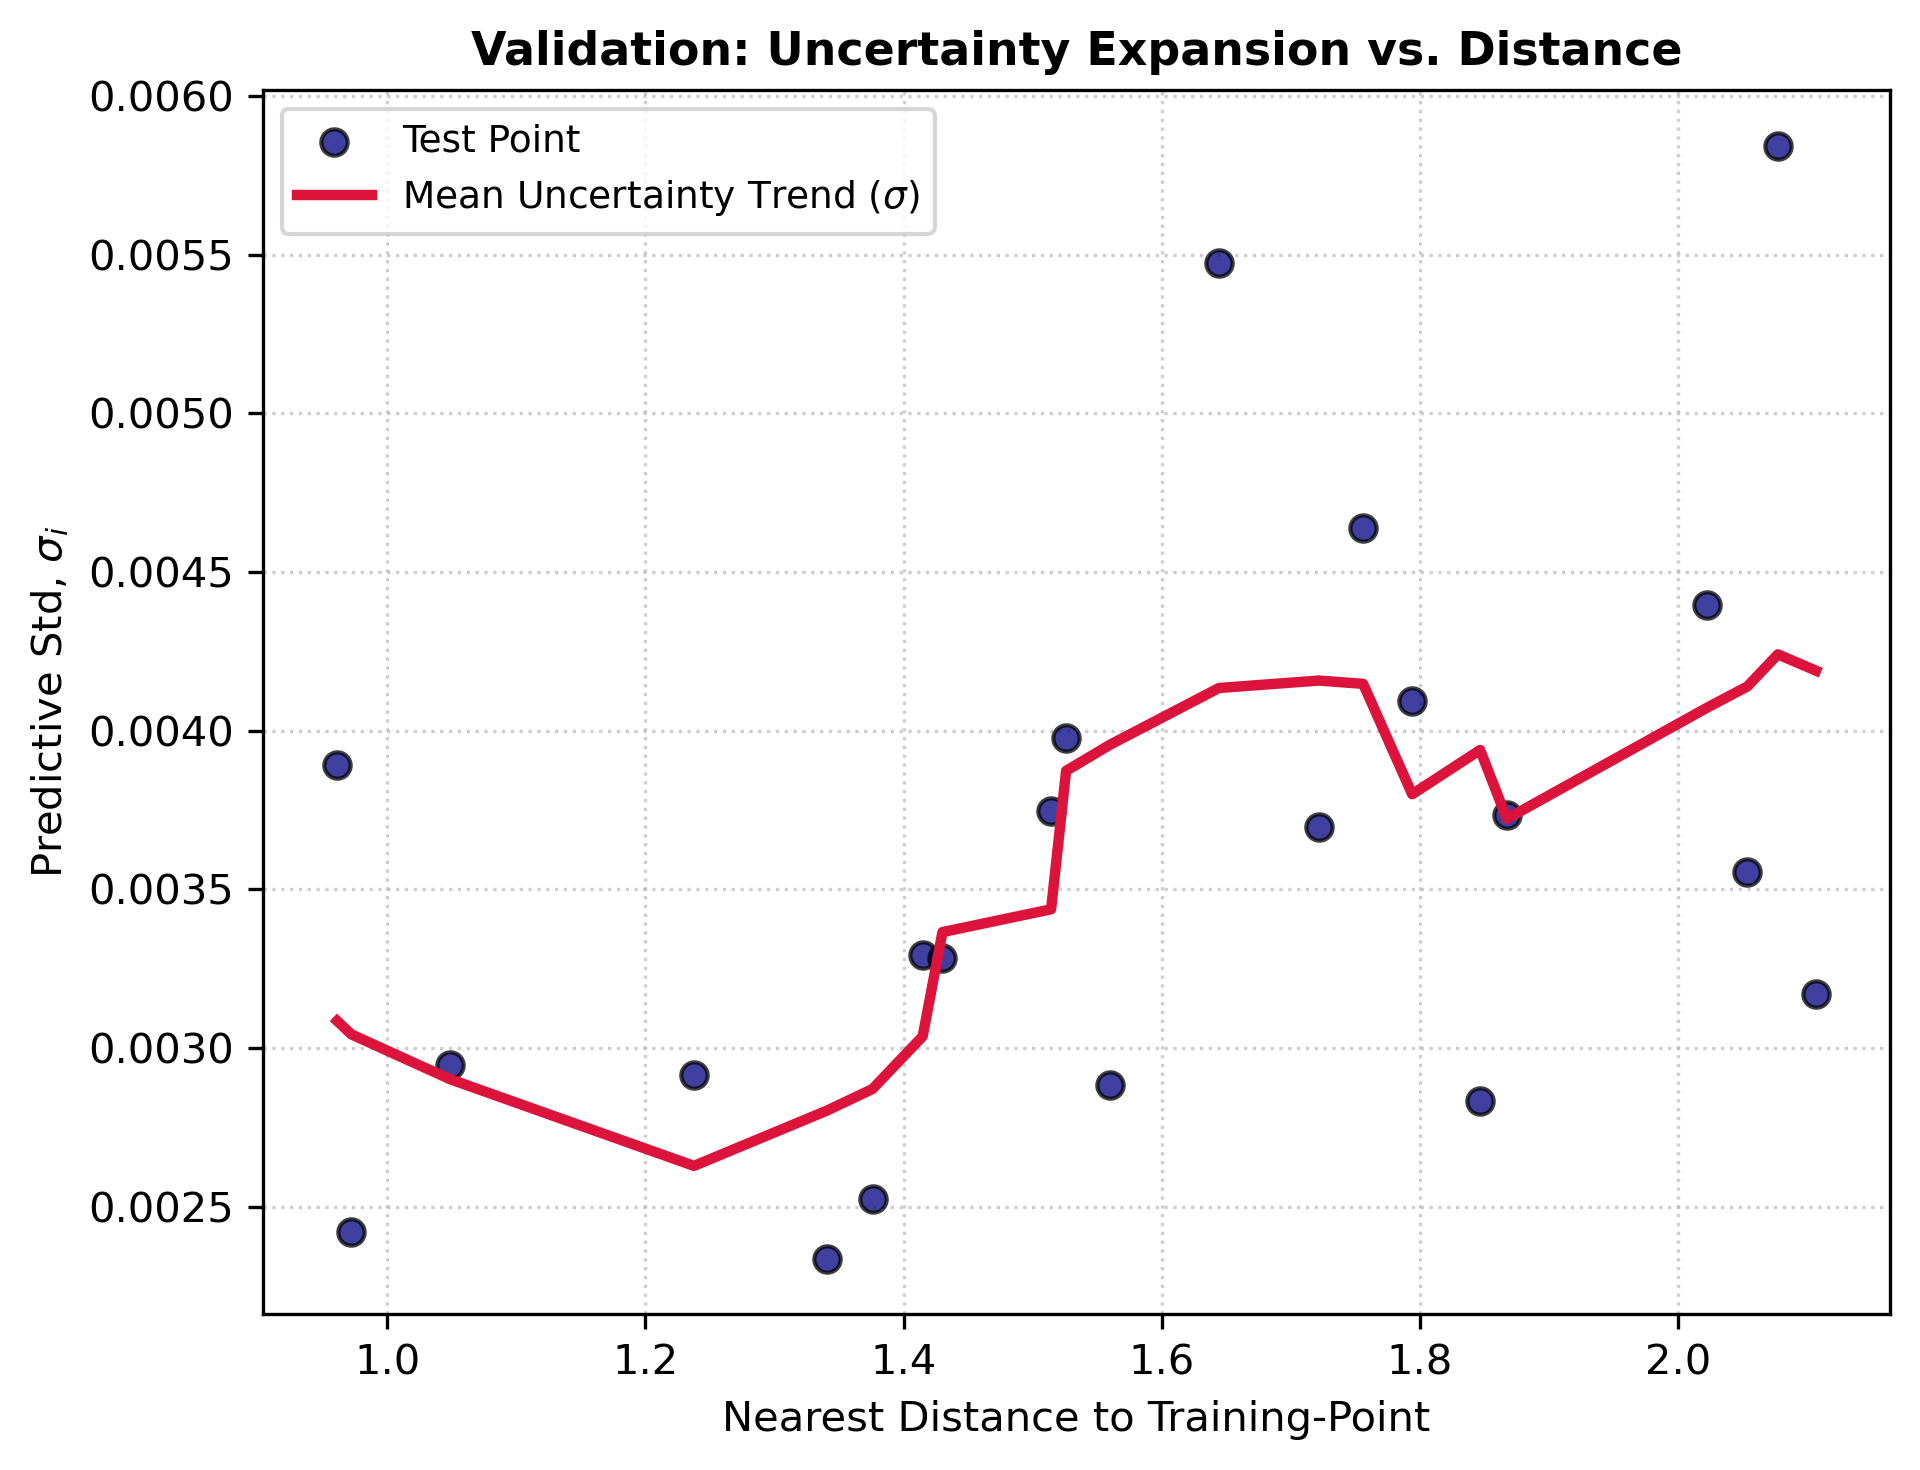

In [16]:
# GP Predictive Uncertainty vs Distance from Training Data
# ==============================================================================
if __name__ == "__main__":
    plt.figure(figsize=(6.5, 5), dpi=300)
    
    # Clustering & Split
    kmeans = KMeans(n_clusters=5, random_state=42).fit(X_data)
    labels = kmeans.labels_
    
    train_idx = np.where(labels != 4)[0]
    test_idx = np.where(labels == 4)[0]
    
    # Train GP
    GPR.load_data(X_data, y_data, train_idx, test_idx)
    GPR.opt_hyper()
    
    mu, std, _ = GPR.predict(GPR.X_test)
    
    X_train = np.array(GPR.X_train)
    X_test_phy = np.array(GPR.X_test)
    
    # Compute Distance
    X_tr_scaled = X_train
    # scale input
    X_te_cont_scaled = GPR.X_scaler.transform(X_test_phy[:, :7])
    X_te_scaled = np.hstack((X_te_cont_scaled, X_test_phy[:, 7:8]))

    
    nn = NearestNeighbors(n_neighbors=1).fit(X_tr_scaled)
    distances, _ = nn.kneighbors(X_te_scaled)
    
    nearest_dist = distances.flatten()
    sigma = np.array(std)
    
    # Sort indecies
    sort_idx = np.argsort(nearest_dist)
    dist_sorted = nearest_dist[sort_idx]
    sigma_sorted = sigma[sort_idx]
    
    # Apply Gaussian filter for trend curve
    # sigma_smooth = ndimage.gaussian_filter1d(sigma_sorted, sigma=3)
    
    # Derive rolling mean of the 5 nearest neighboring points
    sigma_smooth = pd.Series(sigma_sorted).rolling(window=5, center=True, min_periods=1).mean()
    plt.scatter(
        nearest_dist,
        sigma,
        color="navy",
        edgecolors="k",
        s=40,
        alpha=0.75,
        zorder=3,
        label="Test Point"
    )
    
    plt.plot(
        dist_sorted,
        sigma_smooth,
        color="crimson",
        linewidth=2.5,
        zorder=4,
        label=r"Mean Uncertainty Trend ($\sigma$)"
    )
    
    plt.xlabel("Nearest Distance to Training-Point", fontsize=10)
    plt.ylabel(r"Predictive Std, $\sigma_i$", fontsize=10)
    plt.title("Validation: Uncertainty Expansion vs. Distance", fontsize=11, fontweight='bold')
    
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", frameon=True, fontsize=9)
    plt.tight_layout()
    
    plt.savefig("fig_UQ_vs_distance.png")
    plt.show()